In [3]:
import pandas as pd

In [6]:
file_path = "data/HomeDepotCpfData2025_Full_2026-02-01.csv"
df = pd.read_csv(file_path)

In [7]:
df

,month,sku name,sku nbr,state territory code,sub class,region,sales units,sales $
0,Fiscal Period 3 of 2025,"1-1/2"" ABS DOUBLE SANI TEE HXHXHXH",134633,AK,026-001-005-ABS FITTINGS,0012-PACIFIC NORTHWEST,18.0,234.66
1,Fiscal Period 2 of 2024,"1-1/2"" ABS DOUBLE SANI TEE HXHXHXH",134633,AK,026-001-005-ABS FITTINGS,0012-PACIFIC NORTHWEST,6.0,77.35
2,Fiscal Period 5 of 2025,"1-1/2"" ABS DOUBLE SANI TEE HXHXHXH",134633,AK,026-001-005-ABS FITTINGS,0012-PACIFIC NORTHWEST,5.0,65.55
3,Fiscal Period 4 of 2025,"1-1/2"" ABS DOUBLE SANI TEE HXHXHXH",134633,AK,026-001-005-ABS FITTINGS,0012-PACIFIC NORTHWEST,10.0,129.12
4,Fiscal Period 6 of 2025,"1-1/2"" ABS DOUBLE SANI TEE HXHXHXH",134633,AK,026-001-005-ABS FITTINGS,0012-PACIFIC NORTHWEST,12.0,156.01
...,...,...,...,...,...,...,...,...
758294,Fiscal Period 6 of 2025,2 DWV FLUSH CLEANOUT PLUG,1006145870,WY,026-001-031-DWV FITTINGS,0034-PAC MTN DESERT,3.0,11.16
758295,Fiscal Period 5 of 2025,1/2 SCH 40 DEEP SOCKET CPLG,1007427211,WY,026-001-003-PVC FITTINGS,0005-PACIFIC NORTH,1.0,0.96
758296,Fiscal Period 3 of 2024,"1"" SCH 40 DEEP SOCKET CPLG",1007540445,WY,026-001-003-PVC FITTINGS,0034-PAC MTN DESERT,NaN,NaN
758297,Fiscal Period 7 of 2025,"1"" SCH 40 DEEP SOCKET CPLG",1007540445,WY,026-001-003-PVC FITTINGS,0034-PAC MTN DESERT,NaN,NaN


In [10]:
df.columns

Index(['month', 'sku name', 'sku nbr', 'state territory code', 'sub class',
       'region', 'sales units', 'sales $'],
      dtype='str')

In [12]:
df = df.drop(columns=['sku name'])

In [13]:
# extract period and year
df['period'] = df['month'].str.extract(r'Fiscal Period (\d+)').astype(int)
df['year'] = df['month'].str.extract(r'(\d{4})').astype(int)

# convert fiscal period → month (assuming period 1 = Jan)
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['period'].astype(str))

In [14]:
ts = df.groupby('date')['sales units'].sum().sort_index()

In [15]:
ts = ts.asfreq('MS')  # monthly start frequency

In [16]:
train = ts[:'2024-12-01']
test = ts['2025-01-01':]

In [18]:
pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 156.6 kB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 158.6 kB/s eta 0:00:0000:0100:05
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 138.6 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=5)
model_fit = model.fit()

forecast = model_fit.forecast(len(test))

In [26]:
pip install sklearn.metrics

ERROR: Could not find a version that satisfies the requirement sklearn.metrics (from versions: none)
ERROR: No matching distribution found for sklearn.metrics

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)
print(mae)

ModuleNotFoundError: No module named 'sklearn'

In [29]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 130.5 kB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.8/288.8 kB 148.2 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 126.9 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 155.1 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.9 kB/s eta 0:00:0000:0100:04m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 49.2 kB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


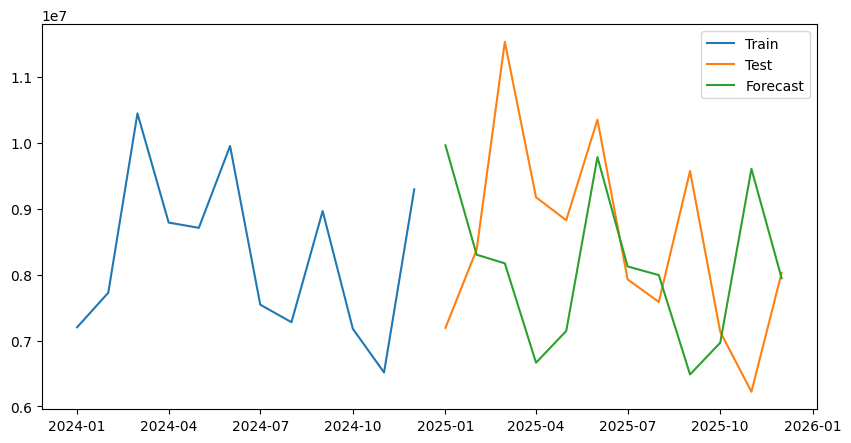

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()